# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Only for the last iteration!

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Asphalt 40°</font>

<font size="6">Test 1: (failed)</font>

Average Fx in the averaging interval [600:None]: 3.941091110691046
Average Fz in the averaging interval [600:None]: -1.3179384280473758
Maximum Fz in the plotting interval [600:None]: 1.1768839518229166 at timestep 1141
Time step where Fx drops below 1: 1140


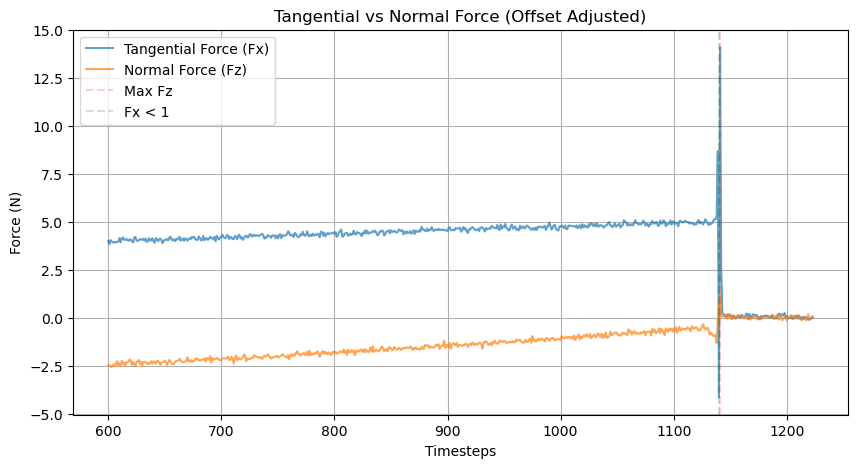

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241438.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, 600, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 1208
Average Fx in the averaging interval [440:1648]: 5.052364419732926
Average Fz in the averaging interval [440:1648]: 1.9192052340139092
Maximum Fz in the plotting interval [440:None]: 5.422037760416667 at timestep 1630
Time step where Fx drops below 1: 1651


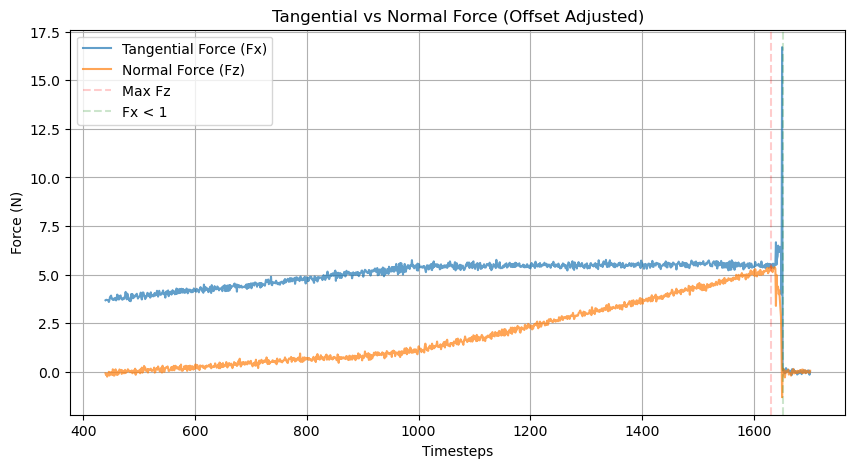

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241440.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, 440, avg_end=1651-3, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 1039
Average Fx in the averaging interval [410:1449]: 5.929494046507105
Average Fz in the averaging interval [410:1449]: 2.472973433082441
Maximum Fz in the plotting interval [410:None]: 4.68955078125 at timestep 1419
Time step where Fx drops below 1: 1452


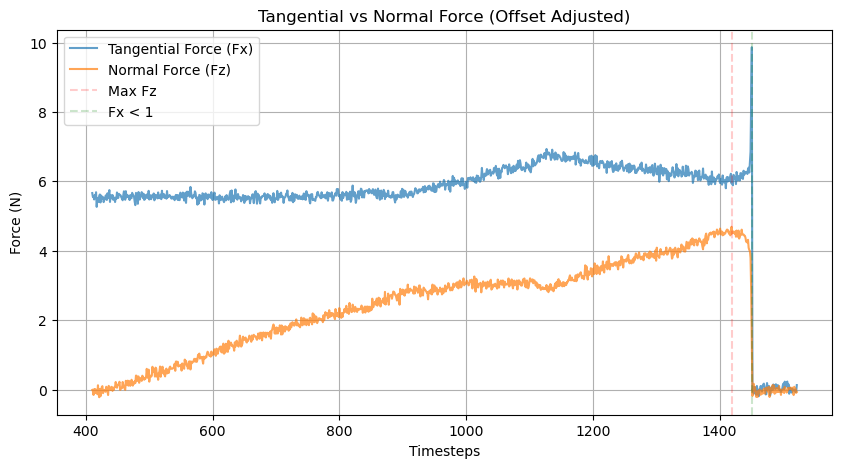

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241441.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df,410, avg_end=1452-3, offset_position='end', offset_length=15)

<font size="6">Test 4: (failed)</font>

Average Fx in the averaging interval [250:None]: 3.148610188552688
Average Fz in the averaging interval [250:None]: -1.1266241196549838
Maximum Fz in the plotting interval [250:None]: 0.19090983072916667 at timestep 1082
Time step where Fx drops below 1: 1023


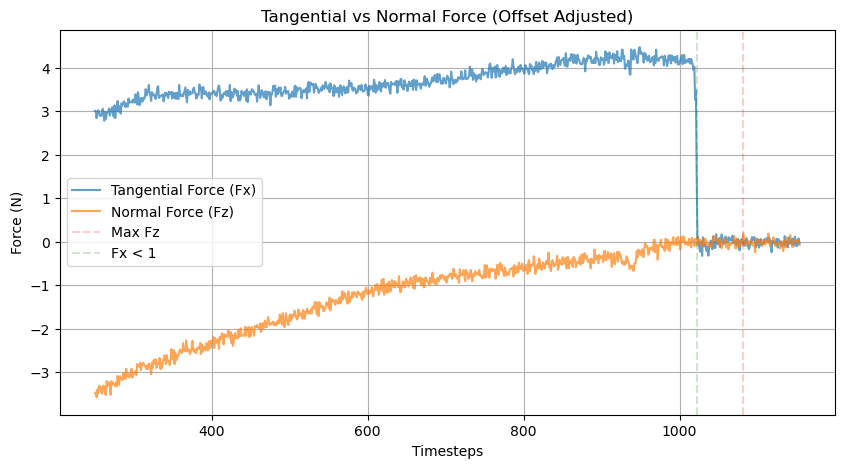

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241443.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, 250, avg_end=None, offset_position='end', offset_length=15)

<font size="6">Test 5: (worked halfway)</font>

Length from cut_1 to avg_end: 215
Average Fx in the averaging interval [100:315]: 4.033368405260781
Average Fz in the averaging interval [100:315]: -0.6704921042272287
Maximum Fz in the plotting interval [100:315]: 0.25486246744791663 at timestep 283
Time step where Fx drops below 1: 295


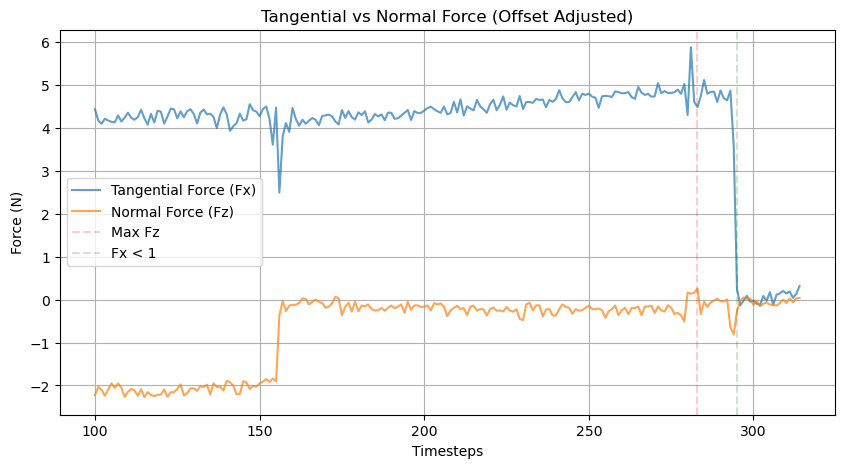

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241444.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=100, cut_2=315, avg_end=None, offset_position='beginning', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 164
Average Fx in the averaging interval [963:1127]: 4.4626499882558495
Average Fz in the averaging interval [963:1127]: 0.19725326910251528
Maximum Fz in the plotting interval [963:1200]: 0.556072998046875 at timestep 1054
Time step where Fx drops below 1: 1127


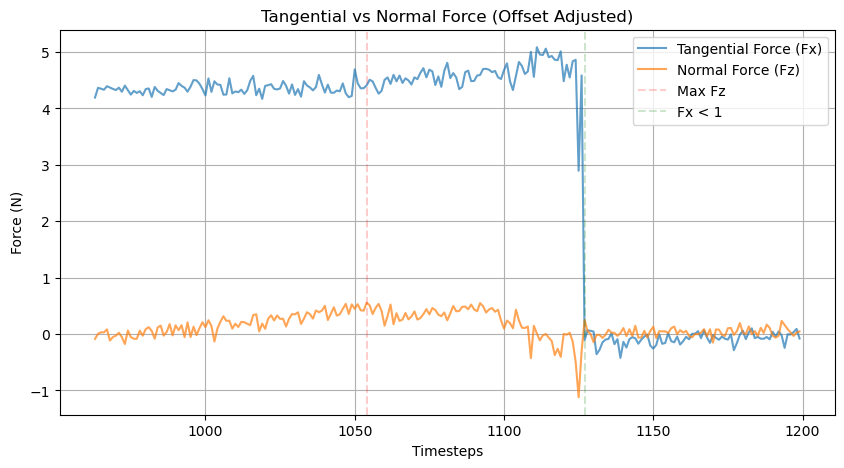

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241445.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=963, cut_2=1200, avg_end=1127, offset_position='end', offset_length=20)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 428
Average Fx in the averaging interval [440:868]: 3.4311524487730125
Average Fz in the averaging interval [440:868]: 0.25962916103850275
Maximum Fz in the plotting interval [440:None]: 0.6703572591145833 at timestep 860
Time step where Fx drops below 1: 869


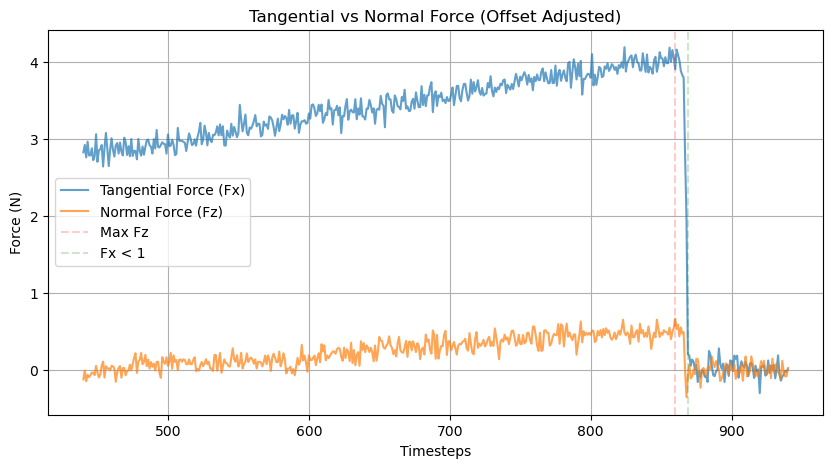

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241447.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=440, cut_2=None, avg_end=868, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 366
Average Fx in the averaging interval [530:896]: 5.738724781776386
Average Fz in the averaging interval [530:896]: 0.31394012951460026
Maximum Fz in the plotting interval [530:950]: 0.676776123046875 at timestep 807
Time step where Fx drops below 1: 897


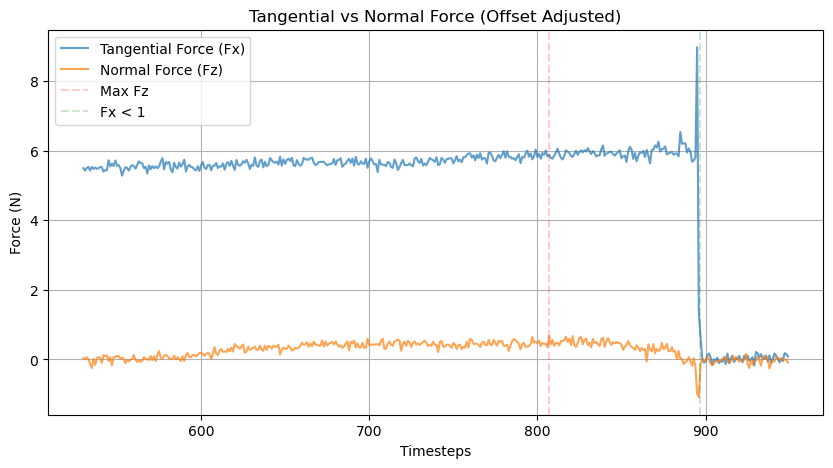

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241448.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=530, cut_2=950, avg_end=896, offset_position='beginning', offset_length=10)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 277
Average Fx in the averaging interval [155:432]: 4.872821434023292
Average Fz in the averaging interval [155:432]: 0.5992441188844388
Maximum Fz in the plotting interval [155:450]: 1.2652180989583333 at timestep 422
Time step where Fx drops below 1: nan


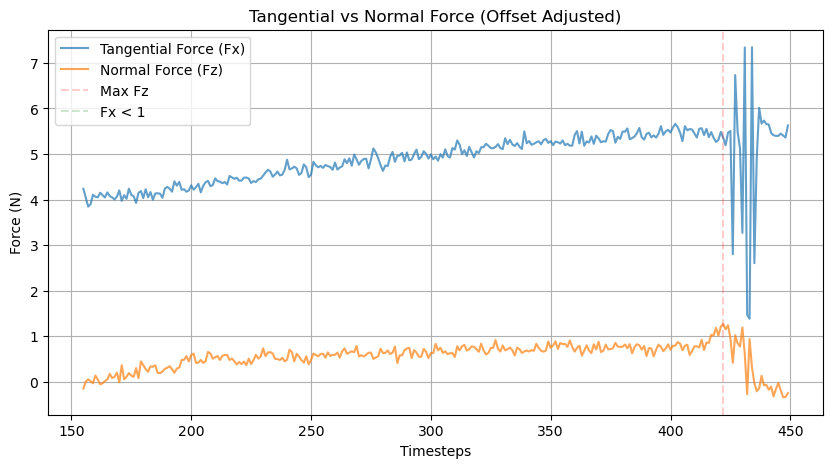

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241449.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=155, cut_2=450, avg_end=432, offset_position='beginning', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 426
Average Fx in the averaging interval [910:1336]: 4.779321753922763
Average Fz in the averaging interval [910:1336]: 1.1650500516936255
Maximum Fz in the plotting interval [910:None]: 2.8202178955078123 at timestep 1321
Time step where Fx drops below 1: 1336


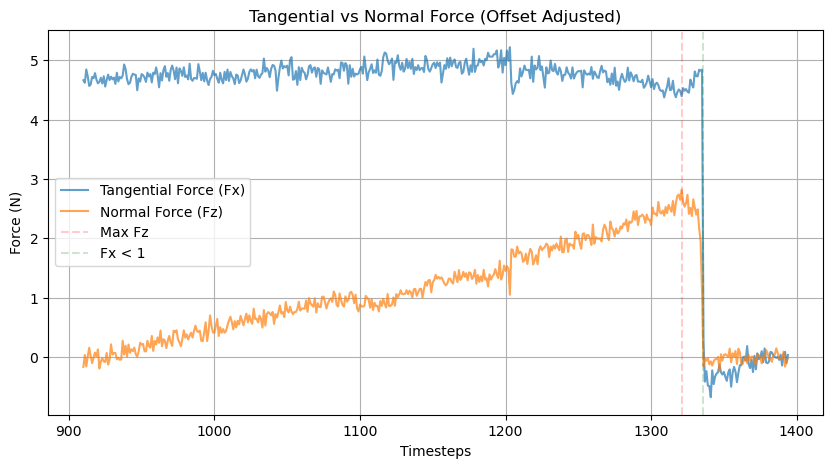

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Asphalt_40_5N//log_202405241450.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=910, cut_2=None, avg_end=1336, offset_position='end', offset_length=20)

In [13]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [59]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//40//Asphalt_40_stats.csv", index=False)

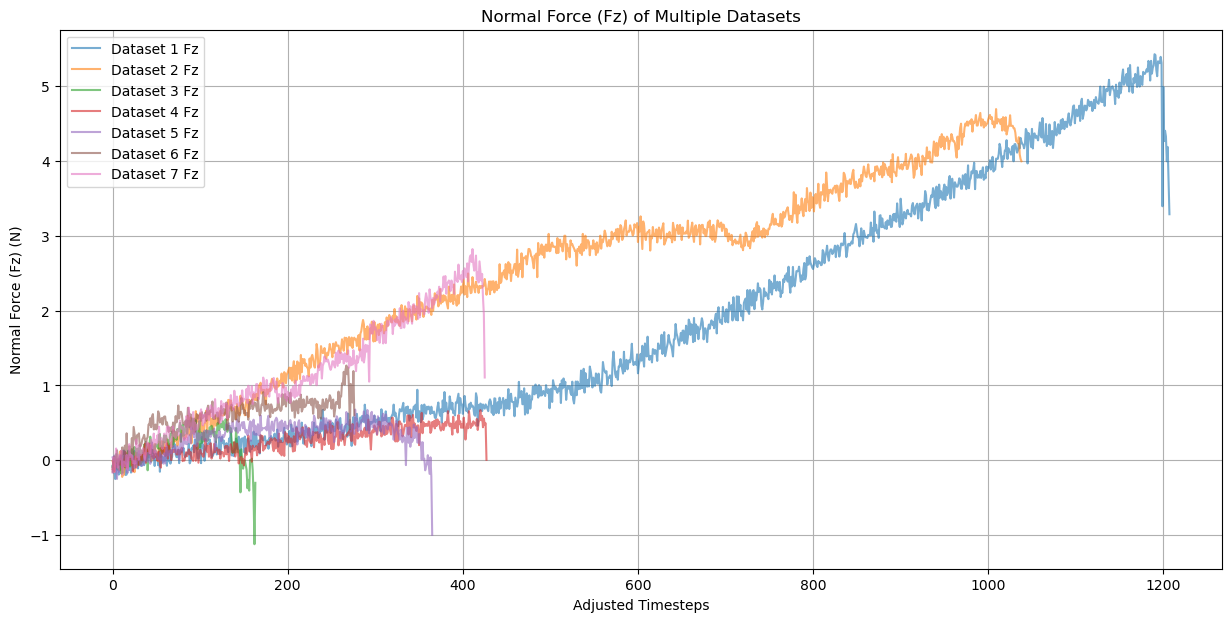

Average of maximum Fz forces: 2.300032988048735
Standard deviation of maximum Fz forces: 1.894742558966973
Average of average Fz forces: 0.9896136281900046
Standard deviation of average Fz forces: 0.833658896896599
Average of average Fx forces: 4.895218410427334
Standard deviation of average Fx forces: 0.770015046013577


In [60]:
tests = [test_2, test_3, test_6, test_7, test_8, test_9, test_10]
ends = [end_2, end_3, end_6, end_7, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [61]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//40//Asphalt_40"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)